# DATA CLEANING

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
dataframe = pd.read_csv('/Users/jacobkuriakose/Library/Containers/com.microsoft.Excel/Data/Downloads/Covid_Data_Raw_Dataset.csv')
dataframe.sort_values(by='AGE', ascending=True, inplace=True)
dataframe

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
503417,2,12,2,2,9999-99-99,2,2,0,97,2,...,2,2,2,2,2,2,2,2,3,2
424308,1,9,2,1,9999-99-99,97,2,0,97,2,...,2,2,2,2,2,2,2,2,7,97
877108,1,12,2,1,9999-99-99,97,2,0,97,2,...,2,2,2,2,2,2,2,2,7,97
15136,1,3,1,2,9999-99-99,2,2,0,2,2,...,2,2,2,2,2,2,2,2,7,2
932751,2,12,2,1,9999-99-99,97,2,0,97,2,...,2,2,2,2,2,2,2,2,7,97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394735,2,9,2,1,9999-99-99,97,1,120,97,1,...,2,2,1,2,2,1,2,1,1,97
690811,2,12,2,1,9999-99-99,97,2,120,97,2,...,2,2,2,2,2,2,2,2,6,97
676023,2,12,2,1,9999-99-99,97,2,120,97,2,...,2,2,2,2,2,2,2,2,5,97
820255,2,12,1,1,9999-99-99,97,2,120,98,2,...,2,2,2,2,2,2,2,2,7,97


In [5]:
#Replacing the value '2' in all columns except the column 'CLASSICATION_FINAL'

cols_to_replace = dataframe.columns.difference(['CLASIFFICATION_FINAL','AGE'])
dataframe.loc[:, cols_to_replace] = dataframe.loc[:, cols_to_replace].replace(2, 0)

In [6]:
#Changing the value 97 in column Preganant and dropping the rows in column Pregnant with value 98

dataframe.loc[(dataframe['SEX'] == 0) & (dataframe['PREGNANT'] == 97), 'PREGNANT'] = 0
dataframe = dataframe[dataframe['PREGNANT'] != 98]

In [7]:
#Replacing the values 97,98,99 in all columns except 'AGE'

column_to_replace = dataframe.columns.drop(['AGE','PREGNANT'])
dataframe[column_to_replace] = dataframe[column_to_replace].replace([97, 98, 99], np.nan)

In [8]:
#Replacing values 4 to 0 , 5,6,7 to nan in column 'CLASSIFICATION_FINAL' without affecting the column 'AGE'

dataframe.loc[dataframe['CLASIFFICATION_FINAL'] == 4, 'CLASIFFICATION_FINAL'] = 0
dataframe.loc[dataframe['CLASIFFICATION_FINAL'].isin([5,6,7]), 'CLASIFFICATION_FINAL'] = float('nan')

In [9]:
#Changing Date fromat
dataframe["MONTH"] = dataframe.DATE_DIED.str.split("/", expand = True)[1]
dataframe["YEAR"] = dataframe.DATE_DIED.str.split("/", expand = True)[2]
dataframe['DIED'] = dataframe['DATE_DIED'].astype(str).apply(lambda x: 0 if x == '9999-99-99' else 1)
dataframe.drop('DATE_DIED', axis=1, inplace=True)

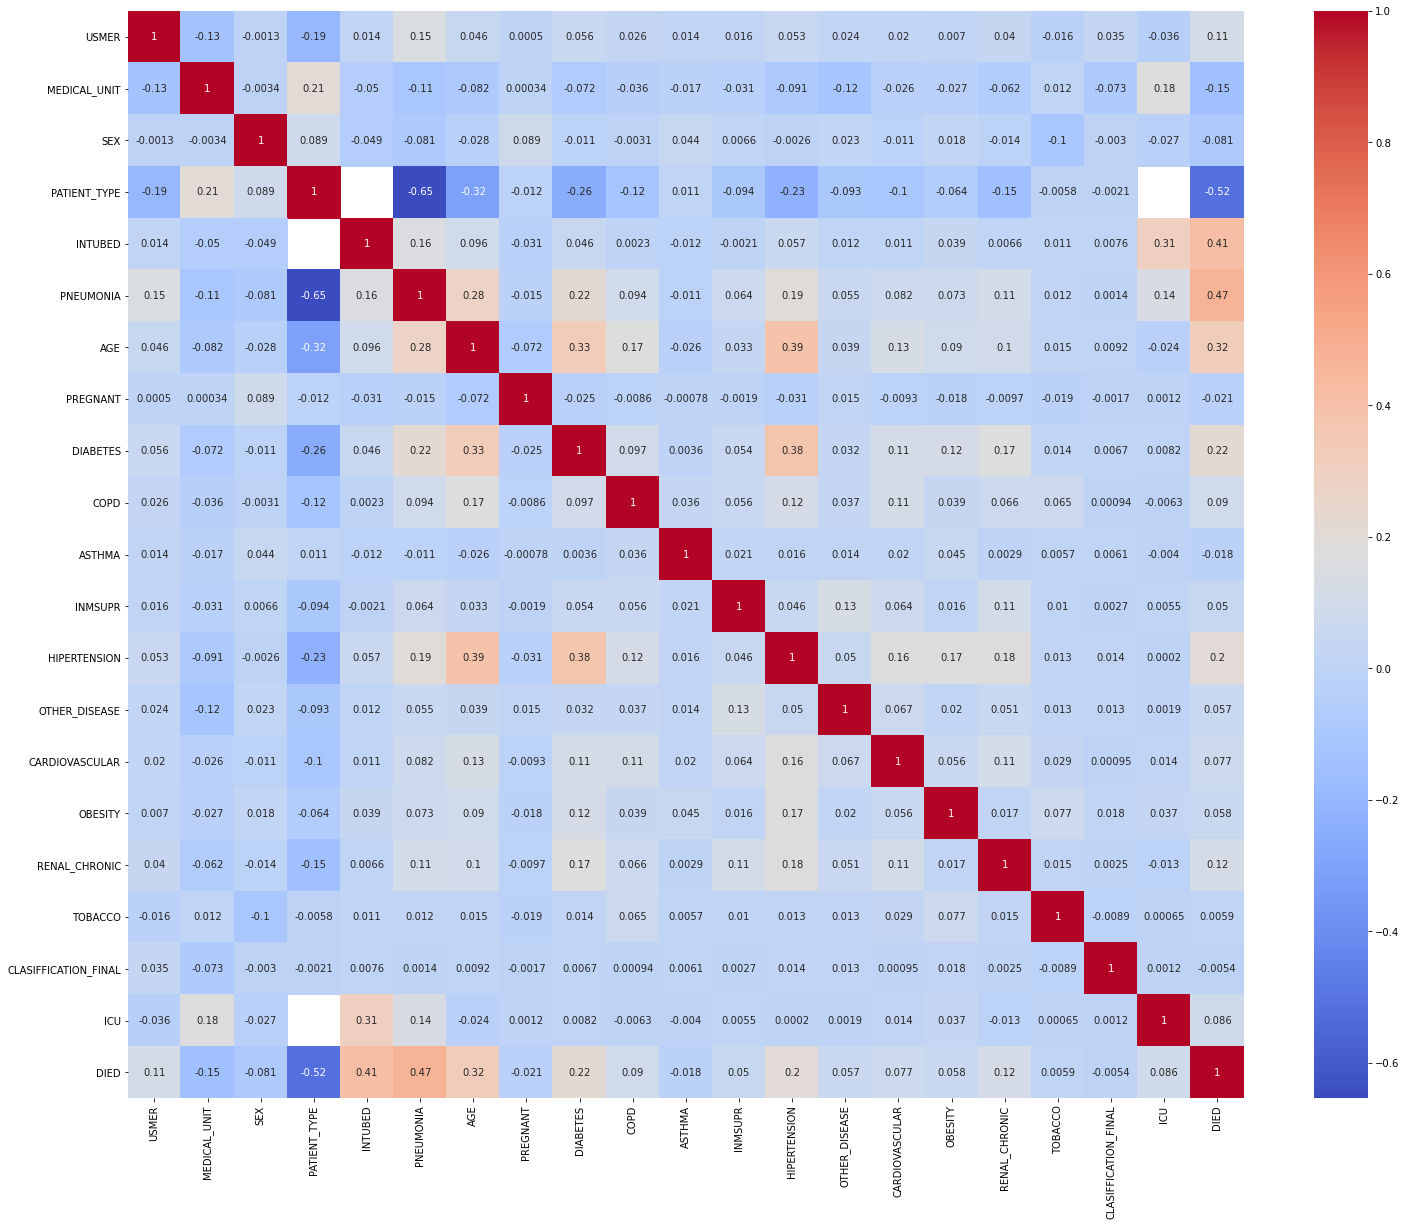

In [10]:
#Plotting Heatmap to drop irrelavant columns

plt.figure(figsize=(25, 20))
corr = dataframe.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [11]:
#Defining coumns of Cleaned Data set. Columns such as "PATIENT_TYPE","OTHER_DISEASE","MEDICAL_UNIT" aren't considered as they have low corelation

cols = ['SEX', 'AGE', 'PNEUMONIA', 'PREGNANT', 'DIABETES', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'CARDIOVASCULAR', 'COPD', 'RENAL_CHRONIC', 'OBESITY', 'TOBACCO', 'INTUBED', 'ICU','USMER',"DIED","CLASIFFICATION_FINAL"]
dataframe = dataframe[cols]
dataframe

,SEX,AGE,PNEUMONIA,PREGNANT,DIABETES,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,COPD,RENAL_CHRONIC,OBESITY,TOBACCO,INTUBED,ICU,USMER,DIED,CLASIFFICATION_FINAL
503417,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,3.0
424308,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0,NaN
877108,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0,NaN
15136,1.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,NaN
932751,0.0,0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
911976,0.0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,NaN
394735,0.0,120,1.0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,NaN,NaN,0.0,0,1.0
690811,0.0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,NaN
676023,0.0,120,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0,NaN


In [12]:
dataframe.to_csv('Cleaned_covid_data.csv', index = False)